In [18]:
# %% [code]
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical, Sequence
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Conv2D, Multiply, Concatenate, Activation, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Activation, Multiply, Concatenate, Conv2D
import tensorflow.keras.backend as K


In [19]:
# %% [code]
def resize_with_padding(image, target_size=(224, 224)):
    """
    Resize an image while preserving its aspect ratio, padding with black pixels to achieve the target size.
    
    Args:
        image: Input image (as a NumPy array).
        target_size: Tuple (width, height) specifying the desired output size.
    
    Returns:
        The resized and padded image.
    """
    target_w, target_h = target_size
    h, w = image.shape[:2]
    
    # Determine the scaling factor to fit the image within target dimensions
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    # Resize the image to new dimensions
    image_resized = cv2.resize(image, (new_w, new_h))
    
    # Compute padding amounts to center the image
    pad_w = target_w - new_w
    pad_h = target_h - new_h
    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left
    
    # Add black padding
    image_padded = cv2.copyMakeBorder(image_resized, top, bottom, left, right,
                                      cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return image_padded


In [20]:
# %% [code]
class TxtDataSequence(Sequence):
    def __init__(self, filepaths, labels, batch_size=32, target_size=(224,224), shuffle=True):
        self.filepaths = filepaths
        self.labels = labels
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, index):
        start = index * self.batch_size
        end = min((index+1) * self.batch_size, len(self.filepaths))
        batch_indices = self.indices[start:end]
        X = []
        batch_labels = []
        for i in batch_indices:
            f = self.filepaths[i]
            try:
                # Read the first line to detect delimiter
                with open(f, "r") as file:
                    first_line = file.readline().strip()
                    delimiter = ";" if ";" in first_line else None
                img = np.loadtxt(f, delimiter=delimiter)
            except Exception as e:
                print(f"Error reading {f}: {e}")
                continue
            # Ensure image has a channel dimension
            if img.ndim == 2:
                img = np.expand_dims(img, axis=-1)
            # Convert grayscale to 3-channel if needed
            if img.shape[-1] == 1:
                img = np.concatenate([img, img, img], axis=-1)
            # Resize image with padding to maintain aspect ratio
            img_padded = resize_with_padding(img, target_size=self.target_size)            # Convert to float and apply ResNet50 preprocessing
            img_padded = img_padded.astype('float32')
            img_processed = preprocess_input(img_padded)
            X.append(img_processed)
            batch_labels.append(self.labels[i])
        if not X:
            return np.empty((0, *self.target_size, 3)), np.empty((0, 2))
        X = np.array(X)
        y = to_categorical(np.array(batch_labels), num_classes=2)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


In [21]:
# %% [code]
# Use the 'segmented(txt)' folder (instead of 'original(txt)')
dataset_dir = os.path.join('datasets', 'segmented(txt)')

# Load file paths and labels
filepaths, labels = load_txt_dataset(dataset_dir)
total_samples = len(filepaths)
print("Total samples:", total_samples)

# Split dataset: 80% training, 20% test (with stratification)
train_filepaths, test_filepaths, train_labels, test_labels = train_test_split(
    filepaths, labels, test_size=0.2, random_state=42, stratify=labels
)
print("Training samples:", len(train_filepaths))
print("Test samples:", len(test_filepaths))
print("Training class distribution:", Counter(train_labels))


Total samples: 258
Training samples: 206
Test samples: 52
Training class distribution: Counter({0: 135, 1: 71})


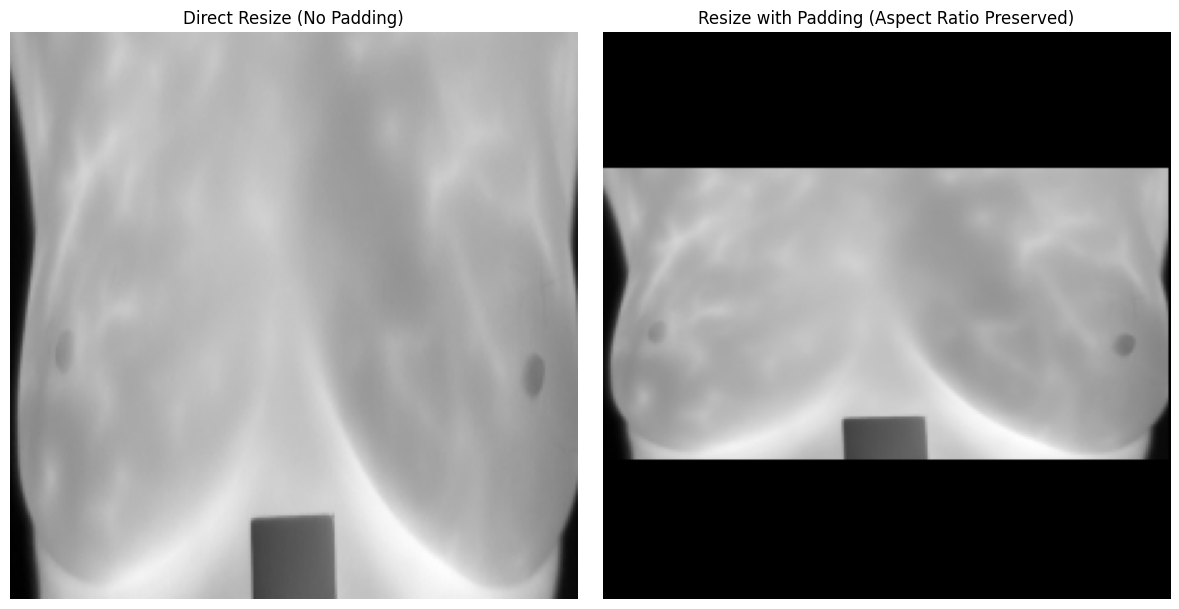

In [23]:
def resize_with_padding(image, target_size=(224,224), pad_color=0):
    """
    Resize an image to fit into target_size while preserving the aspect ratio,
    then pad with a constant color to match the target size.
    
    Parameters:
      - image: input image (numpy array)
      - target_size: tuple (target_height, target_width)
      - pad_color: color for padding (default: 0 for black)
      
    Returns:
      Padded image of size target_size.
    """
    target_h, target_w = target_size
    h, w = image.shape[:2]
    
    # Compute scale factor to fit image inside target_size
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    
    # Resize the image using INTER_AREA for better quality when shrinking
    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Create a new image of target size and fill it with the pad_color
    if len(image.shape) == 3:
        padded_image = np.full((target_h, target_w, image.shape[2]), pad_color, dtype=image.dtype)
    else:
        padded_image = np.full((target_h, target_w), pad_color, dtype=image.dtype)
    
    # Compute top-left corner to center the resized image
    x_offset = (target_w - new_w) // 2
    y_offset = (target_h - new_h) // 2
    
    # Place the resized image onto the padded image
    padded_image[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized_image
    
    return padded_image

def visualize_resize(image, target_size=(224,224)):
    """
    Returns two versions of the resized image:
      1. Directly resized to target_size (which may distort the aspect ratio)
      2. Resized with padding (preserving the aspect ratio by centering the image)
    """
    # Direct resizing without padding (may distort image)
    direct_resized = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
    
    # Resizing with padding using the function defined above
    padded = resize_with_padding(image, target_size=target_size)
    
    return direct_resized, padded

# --- Example usage ---

# Assume filepaths is defined (e.g., from your load_txt_dataset function)
# For example, pick the 4th file from the list (change the index as needed)
example_file = filepaths[3]

try:
    with open(example_file, "r") as file:
        first_line = file.readline().strip()
        delimiter = ";" if ";" in first_line else None
    example_img = np.loadtxt(example_file, delimiter=delimiter)
except Exception as e:
    print(f"Error reading {example_file}: {e}")

# Ensure the image has 3 channels: if it's grayscale, replicate the channel
if example_img.ndim == 2:
    example_img = np.expand_dims(example_img, axis=-1)
if example_img.shape[-1] == 1:
    example_img = np.concatenate([example_img, example_img, example_img], axis=-1)

# Optionally, normalize the image if values are not in 0-255 for clearer display
img_min, img_max = example_img.min(), example_img.max()
if img_max - img_min > 0:
    example_img = ((example_img - img_min) / (img_max - img_min) * 255).astype(np.uint8)
else:
    example_img = example_img.astype(np.uint8)

# Obtain both resized versions
direct_resized, padded = visualize_resize(example_img, target_size=(224,224))

# Plot both images side by side
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Direct Resize (No Padding)")
plt.imshow(direct_resized)
plt.axis('off')
plt.subplot(1,2,2)
plt.title("Resize with Padding (Aspect Ratio Preserved)")
plt.imshow(padded)
plt.axis('off')
plt.tight_layout()
plt.show()

In [25]:
# %% [code]
batch_size = 32

train_sequence = TxtDataSequence(train_filepaths, train_labels, batch_size=batch_size, target_size=(224,224), shuffle=True)
test_sequence  = TxtDataSequence(test_filepaths, test_labels, batch_size=batch_size, target_size=(224,224), shuffle=False)

steps_per_epoch_train = len(train_sequence)
steps_per_epoch_test  = len(test_sequence)
print("Steps per epoch (train):", steps_per_epoch_train)
print("Steps per epoch (test):", steps_per_epoch_test)


Steps per epoch (train): 7
Steps per epoch (test): 2


In [26]:

class CBAMLayer(tf.keras.layers.Layer):
    def __init__(self, reduction_ratio=16, kernel_size=7, **kwargs):
        super(CBAMLayer, self).__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
        self.kernel_size = kernel_size

    def build(self, input_shape):
        # input_shape: (batch, H, W, C)
        self.filters = input_shape[-1]
        # Create shared MLP for channel attention
        self.shared_dense1 = Dense(self.filters // self.reduction_ratio, 
                                   activation='relu', 
                                   kernel_initializer='he_normal', 
                                   use_bias=True, 
                                   bias_initializer='zeros')
        self.shared_dense2 = Dense(self.filters, 
                                   kernel_initializer='he_normal', 
                                   use_bias=True, 
                                   bias_initializer='zeros')
        # Create spatial attention convolution
        self.spatial_conv = Conv2D(1, self.kernel_size, padding='same', 
                                   activation='sigmoid', 
                                   kernel_initializer='he_normal', 
                                   use_bias=False)
        super(CBAMLayer, self).build(input_shape)

    def call(self, inputs):
        # Channel Attention Module
        avg_pool = tf.reduce_mean(inputs, axis=[1,2], keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=[1,2], keepdims=True)
        mlp_avg = self.shared_dense2(self.shared_dense1(avg_pool))
        mlp_max = self.shared_dense2(self.shared_dense1(max_pool))
        channel_attention = tf.nn.sigmoid(mlp_avg + mlp_max)
        x = Multiply()([inputs, channel_attention])
        
        # Spatial Attention Module
        # Note: Use average and max along channel axis
        avg_pool_spatial = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_pool_spatial = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
        spatial_attention = self.spatial_conv(concat)
        x = Multiply()([x, spatial_attention])
        return x

    def get_config(self):
        config = super(CBAMLayer, self).get_config()
        config.update({
            "reduction_ratio": self.reduction_ratio,
            "kernel_size": self.kernel_size
        })
        return config


In [27]:
# Define input shape for ResNet50
input_shape = (224, 224, 3)

# Create base model from prebuilt ResNet50 (include_top=False)
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

# # Freeze all layers except the last 5 layers
# for layer in base_model.layers[:-3]:
#     layer.trainable = False
# for layer in base_model.layers[-3:]:
#     layer.trainable = False

# Optionally, verify trainable status
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)

# Add the custom CBAM attention layer after the base model's output
x = base_model.output
x = CBAMLayer()(x)  # Apply custom CBAMLayer
x = GlobalAveragePooling2D()(x)
predictions = tf.keras.layers.Dense(2, activation='softmax')(x)
model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)

model.summary()


0 input_layer_1 True
1 conv1_pad True
2 conv1_conv True
3 conv1_bn True
4 conv1_relu True
5 pool1_pad True
6 pool1_pool True
7 conv2_block1_1_conv True
8 conv2_block1_1_bn True
9 conv2_block1_1_relu True
10 conv2_block1_2_conv True
11 conv2_block1_2_bn True
12 conv2_block1_2_relu True
13 conv2_block1_0_conv True
14 conv2_block1_3_conv True
15 conv2_block1_0_bn True
16 conv2_block1_3_bn True
17 conv2_block1_add True
18 conv2_block1_out True
19 conv2_block2_1_conv True
20 conv2_block2_1_bn True
21 conv2_block2_1_relu True
22 conv2_block2_2_conv True
23 conv2_block2_2_bn True
24 conv2_block2_2_relu True
25 conv2_block2_3_conv True
26 conv2_block2_3_bn True
27 conv2_block2_add True
28 conv2_block2_out True
29 conv2_block3_1_conv True
30 conv2_block3_1_bn True
31 conv2_block3_1_relu True
32 conv2_block3_2_conv True
33 conv2_block3_2_bn True
34 conv2_block3_2_relu True
35 conv2_block3_3_conv True
36 conv2_block3_3_bn True
37 conv2_block3_add True
38 conv2_block3_out True
39 conv3_block1_1_co

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,118,372 (92.00 MB)

 Trainable params: 24,065,252 (91.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [28]:
# %% [code]
# Compile the model with the desired (lower) learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=0.1), loss='categorical_crossentropy', metrics=['accuracy'])

# Set up class weights based on training distribution
total_train = len(train_labels)
weight_for_0 = total_train / (2 * train_labels.count(0))
weight_for_1 = total_train / (2 * train_labels.count(1))
class_weights = {0: weight_for_0, 1: weight_for_1}
print("Class weights:", class_weights)

# Train the model for 10 epochs
epochs = 10
history = model.fit(
    train_sequence,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch_train,
    class_weight=class_weights,
    verbose=1,
    validation_data=test_sequence,
    validation_steps=steps_per_epoch_test
)


Class weights: {0: 0.762962962962963, 1: 1.4507042253521127}


c:\Users\2004a\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.4757 - loss: 4.1165 - val_accuracy: 0.6538 - val_loss: nan
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 6s/step - accuracy: 0.6615 - loss: 0.6944 - val_accuracy: 0.6538 - val_loss: 0.6753
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - accuracy: 0.4982 - loss: 0.7104 - val_accuracy: 0.3462 - val_loss: 0.7212
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 6s/step - accuracy: 0.3908 - loss: 0.7130 - val_accuracy: 0.3462 - val_loss: 0.7283
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - accuracy: 0.3623 - loss: 0.6987 - val_accuracy: 0.6538 - val_loss: 0.6832
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 68s 10s/step - accuracy: 0.6968 - loss: 0.6741 - val_accuracy: 0.6538 - val_loss: 0.6739
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 67s 9s/step - accuracy: 0.6049 - loss: 0.6841 - val_accuracy: 0.3462 - val_loss: 0.7118
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step - accuracy: 0.3601 - loss: 0.7013 - val_accuracy: 0.3462 - val_loss: 0.7187
Epoch 9/10

In [29]:
# %% [code]
eval_loss, eval_accuracy = model.evaluate(test_sequence, steps=steps_per_epoch_test, verbose=1)
print(f"Test Loss: {eval_loss:.4f}")
print(f"Test Accuracy: {eval_accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 834ms/step - accuracy: 0.6546 - loss: 0.6759
Test Loss: 0.6760
Test Accuracy: 0.6538


In [30]:
# %% [code]
predictions = []
true_labels_arr = []

# Collect predictions from test sequence
for X_batch, y_batch in test_sequence:
    if X_batch.size == 0:
        break
    preds = model.predict(X_batch)
    predictions.extend(np.argmax(preds, axis=1))
    true_labels_arr.extend(np.argmax(y_batch, axis=1))

if len(true_labels_arr) == 0:
    raise ValueError("No test samples were processed. Check your data generator.")

predictions = np.array(predictions)[:len(test_filepaths)]
true_labels_arr = np.array(true_labels_arr)[:len(test_filepaths)]

cm = confusion_matrix(true_labels_arr, predictions)
print("Confusion Matrix:\n", cm)

if cm.size == 4:
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"Sensitivity (TPR): {sensitivity:.4f}")
    print(f"Specificity (TNR): {specificity:.4f}")
else:
    print("Confusion matrix dimensions unexpected for binary classification.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Confusion Matrix:
 [[34  0]
 [18  0]]
Sensitivity (TPR): 0.0000
Specificity (TNR): 1.0000


In [18]:

import pandas as pd

# Create a new data sequence for all images with shuffle disabled 
# (to preserve the order of filepaths and labels as loaded)
all_sequence = TxtDataSequence(filepaths, labels, batch_size=32, target_size=(224,224), shuffle=False)

# Generate predictions for all images (265 in your case)
predictions = model.predict(all_sequence, verbose=1)

# Convert softmax output to predicted labels (0 for 'healthy', 1 for 'sick')
predicted_labels = np.argmax(predictions, axis=1)

# Build a DataFrame with Filename, Actual label, and Predicted label
df_results = pd.DataFrame({
    'Filename': filepaths,     # filepaths list as loaded by load_txt_dataset()
    'Actual': labels,          # actual labels (0 or 1)
    'Predicted': predicted_labels  # predicted labels from the model
})

# Optionally, map numeric labels to their class names for readability
label_mapping = {0: 'healthy', 1: 'sick'}
df_results['Actual_Class'] = df_results['Actual'].map(label_mapping)
df_results['Predicted_Class'] = df_results['Predicted'].map(label_mapping)

# Display the table
print(df_results)
# %% [code]
# Save the entire list of predictions to a text file
with open("predictions2.txt", "w") as f:
    f.write(df_results.to_string(index=False))

print("Predictions saved to predictions.txt")


c:\Users\2004a\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step
                                              Filename  Actual  Predicted  \
0    datasets\segmented(txt)\healthy\T0001.1.1.S.20...       0          1   
1    datasets\segmented(txt)\healthy\T0002.1.1.S.20...       0          1   
2    datasets\segmented(txt)\healthy\T0004.1.1.S.20...       0          1   
3    datasets\segmented(txt)\healthy\T0005.1.1.S.20...       0          1   
4    datasets\segmented(txt)\healthy\T0006.1.1.S.20...       0          1   
..                                                 ...     ...        ...   
253  datasets\segmented(txt)\sick\T0415.1.1.S.2019-...       1          1   
254  datasets\segmented(txt)\sick\T0418.1.1.S.2020-...       1          1   
255  datasets\segmented(txt)\sick\T0422.1.1.S.2019-...       1          1   
256  datasets\segmented(txt)\sick\T0424.1.1.S.2019-...       1          1   
257  datasets\segmented(txt)\sick\T0425.1.1.S.2020-...       1          1   

    Actual_Class Predicted_Class  
0  